In [1]:
# LVDT_simulation/tests/run_simulation.ipynb
import sys
sys.path.append('../..')
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from core import data_handler
from core.json_handler import JsonHandler
from core.simulator import SimulatorManager

### excitation iteration and analysis

In [ ]:
input_json_file= "../config/initial_config/demo_lvdt.json"
iter_json_file= "../config/iteration_config/iteration.json"
output_dir = "../data/excitation_frequency"
exc_freq = [5000,6000,7000,8000,9000,10000,20000,30000,40000,50000]
iterations = range(len(exc_freq))
iter_json_filename = ["iteration_" + str(i) + ".json" for i in iterations]
filename = ["lvdt_alucoil_5mm_excitation_frequency_iter_" + str(i) + ".h5" for i in iterations]

for i in iterations:
    jsonmanager = JsonHandler(input_json=input_json_file, output_json = iter_json_filename[i])
    jsonmanager.update_config(["simulation",'signal_frequency'], exc_freq[i])
    jsonmanager.save_config()

    sim_manager = SimulatorManager(input_jsonname=iter_json_filename[i], output_filename=f'{filename[i]}', 
                                   output_dir=output_dir, auto_close=False) 
    sim_manager.run_simulation()

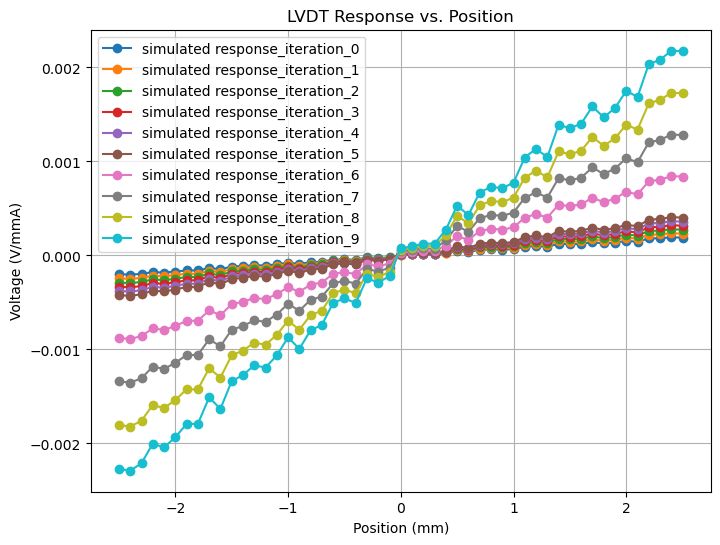

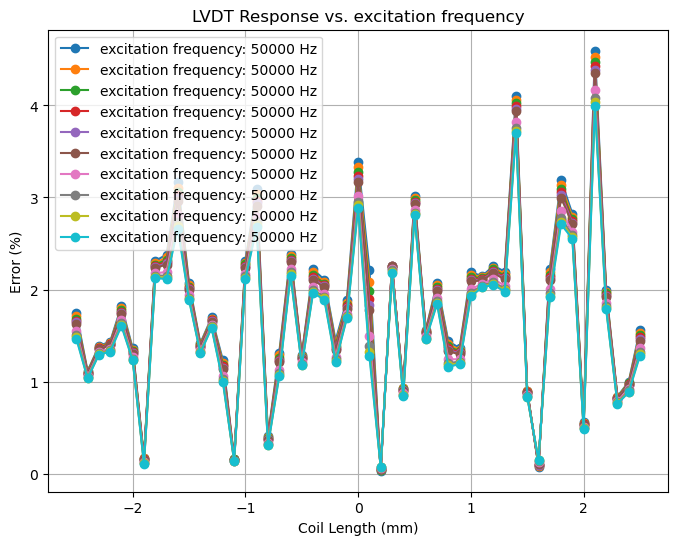

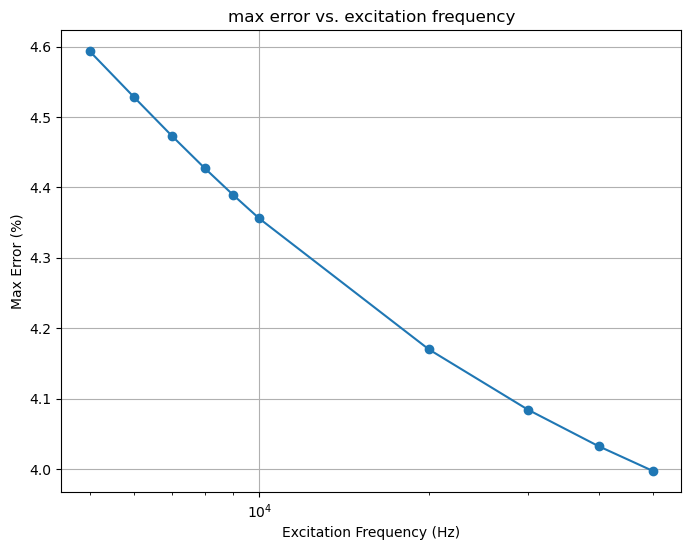

In [2]:
iterations = range(10)
filename = ["lvdt_alucoil_5mm_excitation_frequency_iter_" + str(i) + ".h5" for i in iterations]
sim_files =[f'../data/iter_excitation_frequency/{f}' for f in filename]

lvdt_data = {}

for i, file in enumerate(sim_files):
    data_dict = data_handler.load_data(file)

    config_data = data_handler.get_config_data(data_dict)
    iter_param = config_data['simulation']['signal_frequency']
    
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']

    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params_FS = data_handler.linear_analysis_FS(position, norm_voltage_curr)
    fit_params_RE = data_handler.linear_analysis_RE(position, norm_voltage_curr)
        
    lvdt_data[f"iteration_{i}"] ={
        "position": position,
        "pickup_voltage": pickup_voltage,
        "fit_params": fit_params_FS,
        'excitation_frequency': iter_param,
    }
    
data_handler.plot_linear_fit_mutiple(data_dict = lvdt_data, xlabel = 'Position (mm)', ylabel = 'Voltage (V/mmA)',
                                     title = 'LVDT Response vs. Position')

excitation_frequency = [lvdt_data[f"iteration_{i}"]['excitation_frequency'] for i in range(10)]
errors = [lvdt_data[f"iteration_{i}"]['fit_params']['error'] for i in range(10)]
plt.figure(figsize=(8,6))
for error in errors:
    plt.plot(position, error, marker = 'o', label = f'excitation frequency: {excitation_frequency[i]} Hz')
# plt.plot(excitation_frequency, max(error), 'o-')
plt.xlabel('Coil Length (mm)')
plt.ylabel('Error (%)')
plt.title('LVDT Response vs. excitation frequency')
plt.legend()
plt.grid()
plt.show()

max_errors = [max(error) for error in errors]
plt.figure(figsize=(8,6))
plt.semilogx(excitation_frequency, max_errors, 'o-')
plt.xlabel('Excitation Frequency (Hz)')
plt.ylabel('Max Error (%)')
plt.title('max error vs. excitation frequency')
plt.grid()
plt.show()

### Coil bobbin length iteration and analysis

In [ ]:
input_json_file= "../config/initial_config/config_alucoil_lvdt.json"
iter_json_file= "../config/iteration_config/iteration.json"
output_dir = "../data/coil_length"
coil_length = [1,2,3,4,5,6,7]
iterations = range(len(coil_length))
filename = ["lvdt_alucoil_10mm_coil_length_iter_" + str(i) + ".h5" for i in iterations]

for i in iterations:
    jsonmanager = JsonHandler(input_json=input_json_file, output_json=iter_json_file,)
    jsonmanager.update_config(["coils", 0, "bobbin_length"], coil_length[i])
    jsonmanager.update_config(["coils", 1, "bobbin_length"], coil_length[i])
    jsonmanager.update_config(["coils", 2, "bobbin_length"], coil_length[i])
    jsonmanager.save_config()

    sim_manager = SimulatorManager(input_jsonname=iter_json_file, output_filename=f'{filename[i]}', 
                                   output_dir=output_dir, auto_close=False) 
    sim_manager.run_simulation()

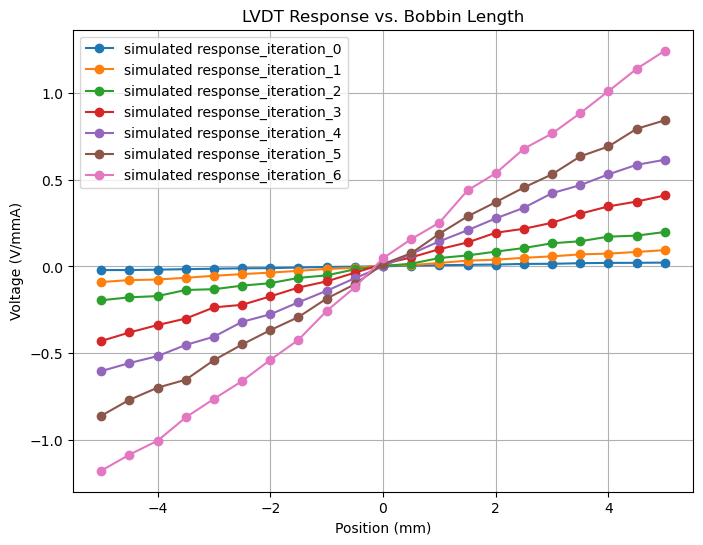

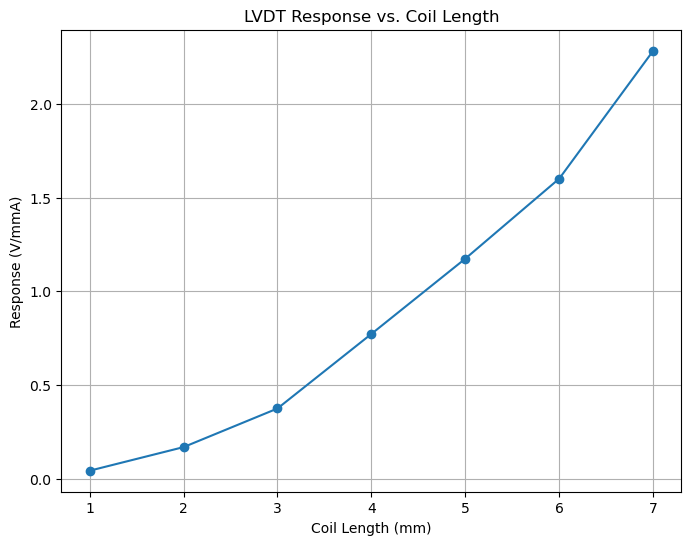

In [3]:
iterations = range(7)
filename = ["lvdt_alucoil_10mm_coil_length_iter_" + str(i) + ".h5" for i in iterations]
sim_files =[f'../data/iter_coil_length/{f}' for f in filename]

lvdt_data = {}

for i, file in enumerate(sim_files):
    data_dict = data_handler.load_data(file)

    config_data = data_handler.get_config_data(data_dict)
    iter_param = config_data['coils']['Middle_Coil']['bobbin_length']
    
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']

    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")
    
    lvdt_data[f"iteration_{i}"] ={
        "position": position,
        "pickup_voltage": pickup_voltage,
        "fit_params": fit_params,
        'bobbin_length': iter_param,
    }


data_handler.plot_linear_fit_mutiple(data_dict = lvdt_data, xlabel = 'Position (mm)', ylabel = 'Voltage (V/mmA)',
                                     title = 'LVDT Response vs. Bobbin Length')

coil_lengths = [lvdt_data[f"iteration_{i}"]['bobbin_length'] for i in range(7)]
responses = [lvdt_data[f"iteration_{i}"]['fit_params']['slope'] for i in range(7)]

plt.figure(figsize=(8,6))
plt.plot(coil_lengths, responses, 'o-')
plt.xlabel('Coil Length (mm)')
plt.ylabel('Response (V/mmA)')
plt.title('LVDT Response vs. Coil Length')
plt.grid()
plt.show()

### Coil layer iteration and analysis

In [ ]:
input_json_file= "../config/initial_config/config_alucoil_lvdt.json"
iter_json_file= "../config/iteration_config/iteration.json"
output_dir = "../data/coil_layers"
coil_layers = [2,4,6,8,10,12,14,16]
iterations = range(len(coil_layers))
filename = ["lvdt_alucoil_10mm_coil_layer_iter_" + str(i) + ".h5" for i in iterations]

for i in iterations:
    jsonmanager = JsonHandler(input_json=input_json_file, output_json=iter_json_file,)
    jsonmanager.update_config(["coils", 0, "layers"], coil_layers[i])
    jsonmanager.update_config(["coils", 1, "layers"], coil_layers[i])
    jsonmanager.update_config(["coils", 2, "layers"], coil_layers[i])
    jsonmanager.save_config()

    sim_manager = SimulatorManager(input_jsonname=iter_json_file, output_filename=f'{filename[i]}', 
                                   output_dir=output_dir, auto_close=False) 
    sim_manager.run_simulation()

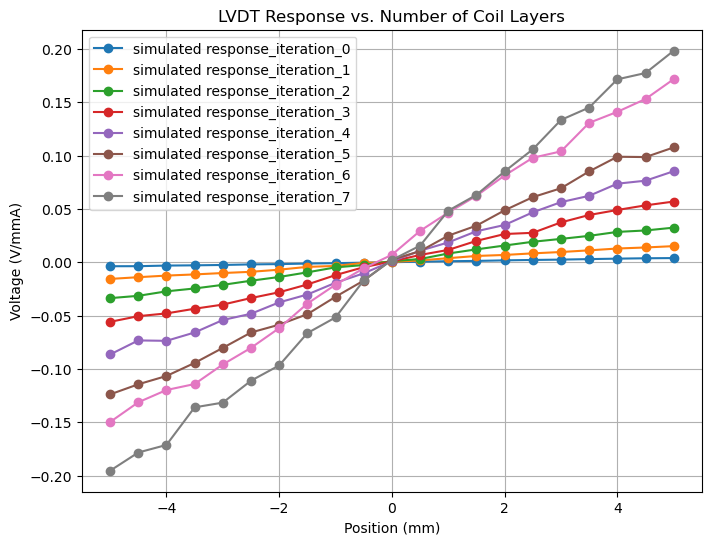

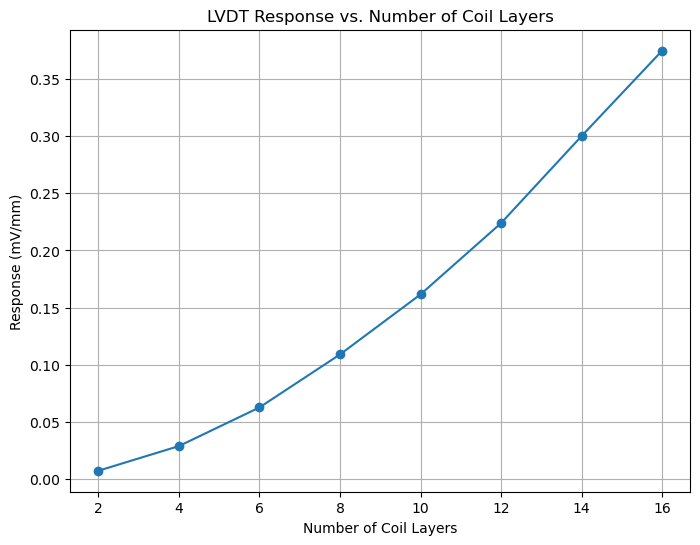

In [4]:
iterations = range(8)
filename = ["lvdt_alucoil_10mm_coil_layer_iter_" + str(i) + ".h5" for i in iterations]
sim_files =[f'../data/iter_coil_layers/{f}' for f in filename]

lvdt_data = {}

for i, file in enumerate(sim_files):
    data_dict = data_handler.load_data(file)

    config_data = data_handler.get_config_data(data_dict)
    iter_param = config_data['coils']['Middle_Coil']['layers']

    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']

    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")
    
    
    lvdt_data[f"iteration_{i}"] ={
        "position": position,
        "pickup_voltage": pickup_voltage, 
        "fit_params": fit_params,
        "coil_layer": iter_param,
    }

data_handler.plot_linear_fit_mutiple(data_dict=lvdt_data, xlabel='Position (mm)', ylabel='Voltage (V/mmA)',
                                     title='LVDT Response vs. Number of Coil Layers')

coil_layers = [lvdt_data[f"iteration_{i}"]['coil_layer'] for i in range(8)]
responses = [lvdt_data[f"iteration_{i}"]['fit_params']['slope'] for i in range(8)]
plt.figure(figsize=(8,6))
plt.plot(coil_layers, responses, 'o-')
plt.xlabel('Number of Coil Layers')
plt.ylabel('Response (mV/mm)')
plt.title('LVDT Response vs. Number of Coil Layers')
plt.grid()
plt.show()


### shell_inndiam iteration and analysis

In [ ]:
input_json_file= "../config/initial_config/config_lvdt_alucoil.json"
iter_json_file= "../config/iteration_config/iteration.json"
output_dir = "../data/shell_inndiam"
shell_inndiam = [6,7,8,9,10,11,12,13]
iterations = range(len(shell_inndiam))
filename = ["lvdt_alucoil_10mm_shell_inndiam_iter_" + str(i) + ".h5" for i in iterations]

for i in iterations:
    jsonmanager = JsonHandler(input_json=input_json_file, output_json=iter_json_file,)
    jsonmanager.update_config(["shells", 0, "inner_diameter"], shell_inndiam[i])
    jsonmanager.save_config()

    sim_manager = SimulatorManager(input_jsonname=iter_json_file, output_filename=f'{filename[i]}', 
                                   output_dir=output_dir, auto_close=False) 
    sim_manager.run_simulation()

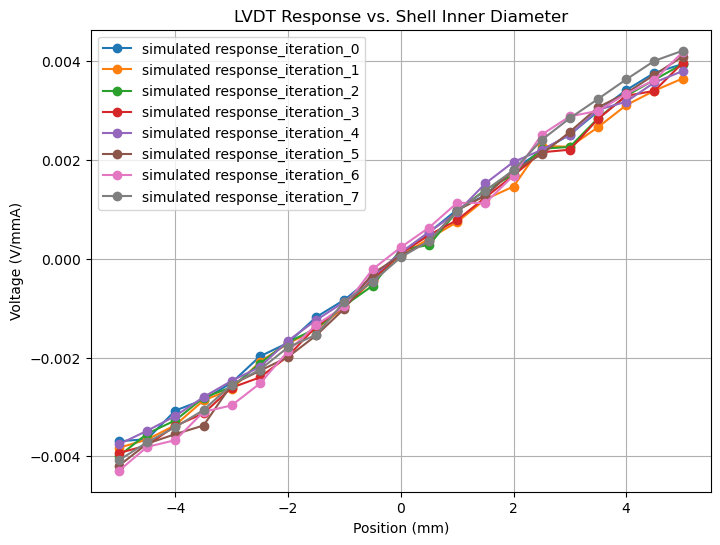

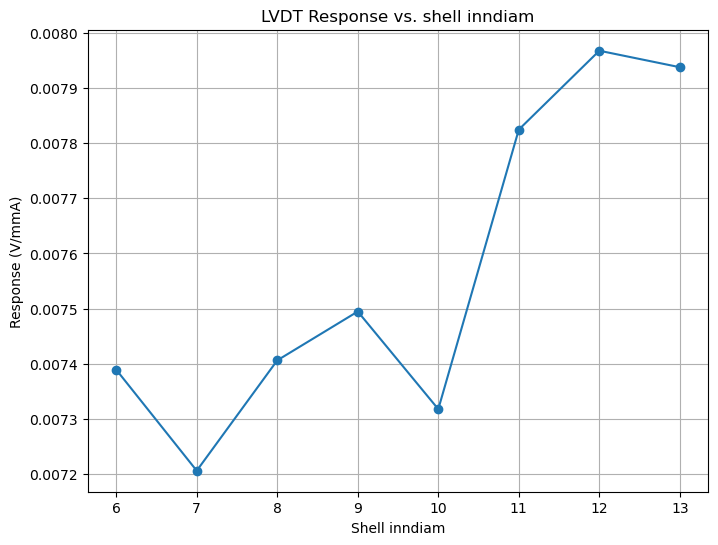

In [5]:
iterations = range(8)
filename = ["lvdt_alucoil_10mm_shell_inndiam_iter_" + str(i) + ".h5" for i in iterations]
sim_files =[f"../data/iter_shell_inndiam/{f}" for f in filename]

lvdt_data = {}
for i, file in enumerate(sim_files):
    data_dict = data_handler.load_data(file)

    config_data = data_handler.get_config_data(data_dict)
    iter_param = config_data['shells']['shell_5']['inner_diameter']
    
    volt_data = data_handler.get_lvdt_data(data_dict, data_type='voltage', flip_sign=True)
    curr_data = data_handler.get_lvdt_data(data_dict, data_type='current')

    position = volt_data['position']
    pickup_voltage = volt_data['Middle_Coil']['voltage_abs']
    excitation_voltage = (abs(volt_data['Upper_Coil']['voltage_abs']*2))
    excitation_current = np.mean(curr_data['Upper_Coil']['current_abs'])

    norm_voltage_volt = pickup_voltage / excitation_voltage
    norm_voltage_curr = pickup_voltage / excitation_current

    fit_params = data_handler.linear_fit(position, norm_voltage_curr, unit="V")

    lvdt_data[f"iteration_{i}"] ={
        "position": position,
        "pickup_voltage": pickup_voltage,
        "fit_params": fit_params,
        "shell_inndiam": iter_param,
    }

data_handler.plot_linear_fit_mutiple(data_dict=lvdt_data, xlabel='Position (mm)', ylabel='Voltage (V/mmA)',
                                        title='LVDT Response vs. Shell Inner Diameter')

shell_inndiams = [lvdt_data[f"iteration_{i}"]['shell_inndiam'] for i in range(8)]
responses = [lvdt_data[f"iteration_{i}"]['fit_params']['slope'] for i in range(8)]

plt.figure(figsize=(8,6))
plt.plot(shell_inndiams, responses, 'o-' )
plt.xlabel('Shell inndiam')
plt.ylabel('Response (V/mmA)')
plt.title('LVDT Response vs. shell inndiam')
plt.grid()
plt.show()